# Tutorial 1: Integrating adjacent DLPFC slices
This tutorial demonstrates STAligner's ablility to integrate multiple adjacent slices. The slices are sampled from human dorsolateral prefrontal cortex (DLPFC) and the processed data can be downloaded from https://drive.google.com/drive/folders/1pHJy2cB9BKqc3ny9IpvVhiw_8ukJMzPW?usp=share_link.

## Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# import ST_utils
# import train_STAligner
import STAligner

# the location of R (used for the mclust clustering)
import os
#os.environ['R_HOME'] = "/home/xzhou/anaconda3/envs/PyG/lib/R"
#os.environ['R_USER'] = "/home/xzhou/anaconda3/envs/PyG/lib/python3.8/site-packages/rpy2"
import rpy2.robjects as robjects
import rpy2.robjects.numpy2ri


import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scipy.linalg


import torch
used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Load Data

In [3]:
Batch_list = []
adj_list = []
section_ids = ['E9.5_E1S1.MOSTA', 'E9.5_E2S1.MOSTA', 'E9.5_E2S2.MOSTA', 'E9.5_E2S3.MOSTA', 'E9.5_E2S4.MOSTA']
print(section_ids)

for section_id in section_ids:
    print(section_id)
    input_dir = os.path.join('../../../data/Mouse_Embryo')
    adata = sc.read_h5ad(os.path.join(input_dir, section_id + '.h5ad'))
    adata.var_names_make_unique(join="++")

    # read the annotation
    # Ann_df = pd.read_csv(os.path.join(input_dir, 'manual_annotations.txt'), sep='\t', header=None, index_col=0)
    # Ann_df.columns = ['Ground Truth']
    # Ann_df[Ann_df.isna()] = "unknown"
    # adata.obs['Ground Truth'] = Ann_df.loc[adata.obs_names, 'Ground Truth'].astype('category')
    
    # make spot name unique
    adata.obs_names = [x+'_'+section_id for x in adata.obs_names]
    
    # Constructing the spatial network
    STAligner.Cal_Spatial_Net(adata, rad_cutoff=1.3) # the spatial network are saved in adata.uns[‘adj’]
    # STAligner.Stats_Spatial_Net(adata) # plot the number of spatial neighbors
    
    # Normalization
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata = adata[:, adata.var['highly_variable']]

    adj_list.append(adata.uns['adj'])
    Batch_list.append(adata)

['E9.5_E1S1.MOSTA', 'E9.5_E2S1.MOSTA', 'E9.5_E2S2.MOSTA', 'E9.5_E2S3.MOSTA', 'E9.5_E2S4.MOSTA']
E9.5_E1S1.MOSTA
------Calculating spatial graph...
The graph contains 23166 edges, 5913 cells.
3.9178 neighbors per cell on average.
E9.5_E2S1.MOSTA
------Calculating spatial graph...
The graph contains 20764 edges, 5292 cells.
3.9237 neighbors per cell on average.
E9.5_E2S2.MOSTA
------Calculating spatial graph...
The graph contains 16982 edges, 4356 cells.
3.8985 neighbors per cell on average.
E9.5_E2S3.MOSTA
------Calculating spatial graph...
The graph contains 19776 edges, 5059 cells.
3.9091 neighbors per cell on average.
E9.5_E2S4.MOSTA
------Calculating spatial graph...
The graph contains 22800 edges, 5797 cells.
3.9331 neighbors per cell on average.


## Concat the scanpy objects for multiple slices

In [4]:
adata_concat = ad.concat(Batch_list, label="slice_name", keys=section_ids)
# adata_concat.obs['Ground Truth'] = adata_concat.obs['Ground Truth'].astype('category')
adata_concat.obs["batch_name"] = adata_concat.obs["slice_name"].astype('category')
print('adata_concat.shape: ', adata_concat.shape)

adata_concat.shape:  (26417, 588)


## Concat the spatial network for multiple slices

In [5]:
adj_concat = np.asarray(adj_list[0].todense())
for batch_id in range(1,len(section_ids)):
    adj_concat = scipy.linalg.block_diag(adj_concat, np.asarray(adj_list[batch_id].todense()))
adata_concat.uns['edgeList'] = np.nonzero(adj_concat)

## Running STAligner

In [6]:
%%time
adata_concat = STAligner.train_STAligner(adata_concat, verbose=True, knn_neigh = 50, device=used_device)

STAligner(
  (conv1): GATConv(588, 512, heads=1)
  (conv2): GATConv(512, 30, heads=1)
  (conv3): GATConv(30, 512, heads=1)
  (conv4): GATConv(512, 588, heads=1)
)
Pretrain with STAGATE...


100%|██████████| 500/500 [00:08<00:00, 61.32it/s]


Train with STAligner...


  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplets at epoch 500


...

Update spot triplets at epoch 800


 80%|████████  | 400/500 [00:48<00:01, 52.26it/s]

Update spot triplets at epoch 900


100%|██████████| 500/500 [01:01<00:00,  8.14it/s]


CPU times: total: 4min 3s
Wall time: 1min 9s


## Clustering

In [7]:
STAligner.ST_utils.mclust_R(adata_concat, num_cluster=13, used_obsm='STAligner')

# louvain
# sc.pp.neighbors(adata_concat, use_rep='STAligner', random_state=666)
# sc.tl.louvain(adata_concat, random_state=666, key_added="louvain", resolution=0.35)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 26417 × 588
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - Alx4', 'Regulon - Arx', 'Regulon - Atf1', 'Regulon - Bach1', 'Regulon - Barhl1', 'Regulon - Bcl3', 'Regulon - Bclaf1', 'Regulon - Bmyc', 'Regulon - Brf1', 'Regulon - Brf2', 'Regulon - Cdx1', 'Regulon - Cebpa', 'Regulon - Creb1', 'Regulon - Creb3l1', 'Regulon - Crx', 'Regulon - Ctcf', 'Regulon - Cux1', 'Regulon - Dbx1', 'Regulon - E2f1', 'Regulon - E2f2', 'Regulon - E2f3', 'Regulon - E2f4', 'Regulon - E2f5', 'Regulon - E2f6', 'Regulon - Egr4', 'Regulon - Elf2', 'Regulon - Elk1', 'Regulon - Elk3', 'Regulon - En1', 'Regulon - Ep300', 'Regulon - Erg', 'Regulon - Esrra', 'Regulon - Ets2', 'Regulon - Etv2', 'Regulon - Etv4', 'Regulon - Etv5', 'Regulon - Evx1', 'Regulon - Ezh2', 'Regulon - Figla', 'Regulon - Fli1', 'Regulon - Foxa1', 'Regulon - Foxa2', 'Regulon - Foxa3', 'Regulon - Foxd1', 'Regulon - Foxf1', 'Regulon - Foxj3',

In [8]:
# sc.tl.umap(adata_concat, random_state=666)
# colors_default = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
#                   '#8c564b', '#e377c2', '#bcbd22', '#17becf', '#aec7e8',
#                   '#ffbb78', '#98df8a', '#ff9896', '#bec1d4', '#bb7784',
#                   '#0000ff']
# adata_concat.uns['louvain_colors'] = [colors_default[0:][i] for i in np.sort(adata_concat.obs['mclust'].unique().astype('int'))]
# 
# import matplotlib.pyplot as plt
# plt.rcParams['font.sans-serif'] = "Arial"
# plt.rcParams["figure.figsize"] = (2, 2)
# plt.rcParams['font.size'] = 10
# 
# sc.pl.umap(adata_concat, color=['batch_name', 'mclust'], ncols=2, wspace=1, show=True)

In [9]:
# for ss in range(len(section_ids)):
#     Batch_list[ss].obs['louvain'] = adata_concat[adata_concat.obs['batch_name'] == section_ids[ss]].obs['mclust'].values
#     Batch_list[ss].uns['louvain_colors'] = [colors_default[0:][i] for i in np.sort(adata_concat[adata_concat.obs['batch_name'] == 
#                                                                             section_ids[ss]].obs['mclust'].unique().astype('int'))]       
# 
# import matplotlib.pyplot as plt
# spot_size = 1
# title_size = 10
# fig, ax = plt.subplots(1, len(section_ids), figsize=(len(section_ids)*3, 3), gridspec_kw={'wspace':1, 'hspace': 0.1})    
# for ss in range(len(section_ids)-1):
#     _sc_0 = sc.pl.spatial(Batch_list[ss], img_key=None, color=['mclust'], title=['mclust'], size=1.5, legend_fontsize=8, 
#                   show=False, frameon=False, ax=ax[ss], spot_size=spot_size)
#     _sc_0[0].set_title(section_ids[ss], size=title_size)
# _sc_0 = sc.pl.spatial(Batch_list[-1], img_key=None, color=['mclust'], title=['mclust'], size=1.5, legend_fontsize=8, 
#               show=False, frameon=False, ax=ax[-1], spot_size=spot_size)
# _sc_0[0].set_title(section_ids[-1], size=title_size)
# plt.show()

In [10]:
adata_concat

AnnData object with n_obs × n_vars = 26417 × 588
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - Alx4', 'Regulon - Arx', 'Regulon - Atf1', 'Regulon - Bach1', 'Regulon - Barhl1', 'Regulon - Bcl3', 'Regulon - Bclaf1', 'Regulon - Bmyc', 'Regulon - Brf1', 'Regulon - Brf2', 'Regulon - Cdx1', 'Regulon - Cebpa', 'Regulon - Creb1', 'Regulon - Creb3l1', 'Regulon - Crx', 'Regulon - Ctcf', 'Regulon - Cux1', 'Regulon - Dbx1', 'Regulon - E2f1', 'Regulon - E2f2', 'Regulon - E2f3', 'Regulon - E2f4', 'Regulon - E2f5', 'Regulon - E2f6', 'Regulon - Egr4', 'Regulon - Elf2', 'Regulon - Elk1', 'Regulon - Elk3', 'Regulon - En1', 'Regulon - Ep300', 'Regulon - Erg', 'Regulon - Esrra', 'Regulon - Ets2', 'Regulon - Etv2', 'Regulon - Etv4', 'Regulon - Etv5', 'Regulon - Evx1', 'Regulon - Ezh2', 'Regulon - Figla', 'Regulon - Fli1', 'Regulon - Foxa1', 'Regulon - Foxa2', 'Regulon - Foxa3', 'Regulon - Foxd1', 'Regulon - Foxf1', 'Regulon - Foxj3',

In [11]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [12]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['annotation'])]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
for name in section_ids:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    ARI = ari_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} ARI:{ARI}")

total ARI:0.2493142424806706
E9.5_E1S1.MOSTA ARI:0.2680731217321636
E9.5_E2S1.MOSTA ARI:0.26355968355827464
E9.5_E2S2.MOSTA ARI:0.3705918473469273
E9.5_E2S3.MOSTA ARI:0.41063931581891366
E9.5_E2S4.MOSTA ARI:0.3216825723246048


In [13]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['annotation'])]
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total AMI:{AMI}")
for name in section_ids:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    AMI = ami_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    ACC = 1/2 * (NMI + AMI)
    print(f"{name} ACC:{ACC}")

total NMI:0.4389276810064365
total AMI:0.4380645488768856
E9.5_E1S1.MOSTA ACC:0.4937526577124345
E9.5_E2S1.MOSTA ACC:0.5074565299547663
E9.5_E2S2.MOSTA ACC:0.5456883723777504
E9.5_E2S3.MOSTA ACC:0.5729110537007442
E9.5_E2S4.MOSTA ACC:0.5186249652149926


In [14]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['annotation'])]
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total COM:{COM}")
for name in section_ids:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    HOM = hom_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    COM = com_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    V =  2 * ((HOM * COM) / (HOM + COM))
    print(f"{name} V:{V}")

total HOM:0.42659600305338186
total COM:0.45199352925571934
E9.5_E1S1.MOSTA V:0.49500931903589585
E9.5_E2S1.MOSTA V:0.5089730559889885
E9.5_E2S2.MOSTA V:0.5472570151695022
E9.5_E2S3.MOSTA V:0.5741003910458915
E9.5_E2S4.MOSTA V:0.5199114592907002


2.3296949310779067
1.7764645404801822


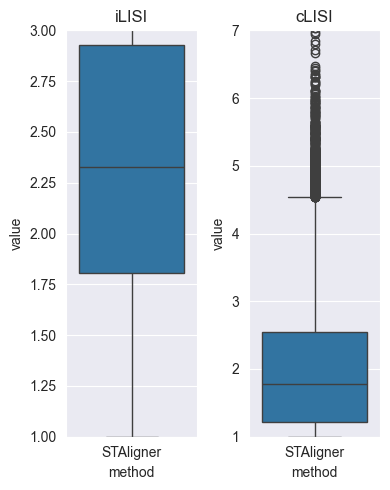

In [15]:
import seaborn as sns
import harmonypy as hm

iLISI = hm.compute_lisi(adata_concat.obsm['STAligner'], adata_concat.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
cLISI = hm.compute_lisi(adata_concat.obsm['STAligner'], adata_concat.obs[['annotation']], label_colnames=['annotation'])[:, 0]

df_iLISI = pd.DataFrame({
    'method': 'STAligner',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

df_cLISI = pd.DataFrame({
    'method': 'STAligner',
    'value': cLISI,
    'type': ['CLISI'] * len(cLISI)
})

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
print(np.median(cLISI))

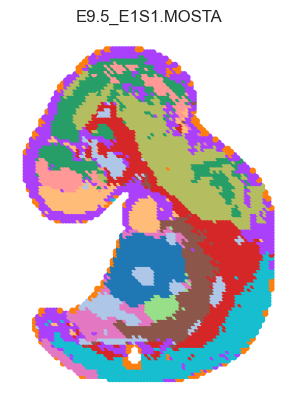

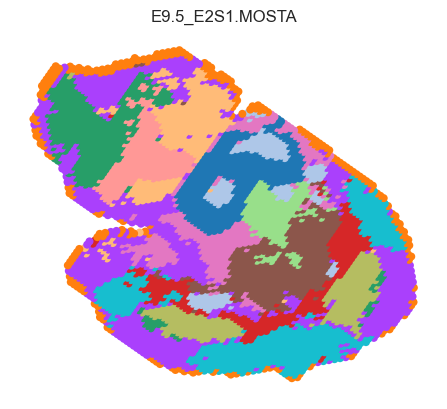

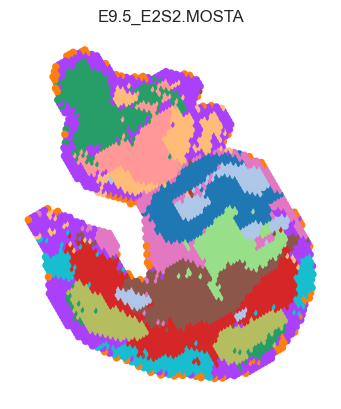

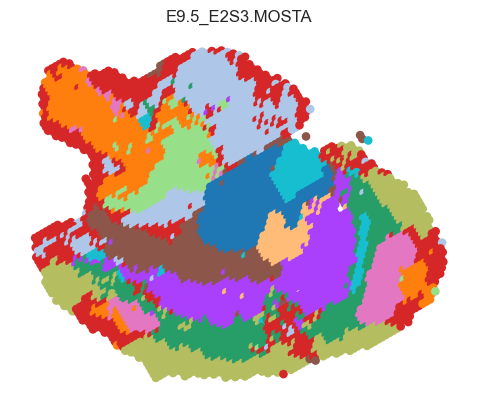

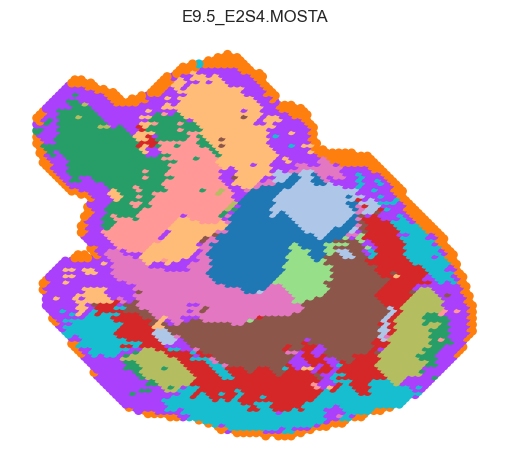

In [16]:
import matplotlib.pyplot as plt

spot_size = 2
for slice_id in section_ids:
    adata_tmp = adata_concat[adata_concat.obs['batch_name'] == slice_id]
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc=None, legend_fontsize=12, show=False, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_id}')
plt.tight_layout()